# Paper plots
Questo notebook genera i plot richiesti dal paper usando i CSV in `../results/`.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

RECORDS = '../results/classification/records.csv'
LRA = '../results/lra_records.csv'
EFF = '../results/efficiency.csv'


In [14]:
# Utils

def load_records():
    df = pd.read_csv(RECORDS, index_col=0)
    df.index.name = 'dataset'
    df['group'] = df.index.str.split('/').str[0]
    df['short'] = df.index.str.split('/').str[1]
    return df


def to_numeric(df):
    return df.apply(pd.to_numeric, errors='coerce')


def kmer_metric_cols(df, metric, include_multi=True):
    cols = [c for c in df.columns if c.startswith('kmer_k') and c.endswith('_' + metric)]
    if include_multi:
        cols += [c for c in df.columns if c.startswith('kmer_multi') and c.endswith('_' + metric)]
    return cols


def fm_metric_cols(df, metric):
    return [c for c in df.columns if c.startswith('fm_') and c.endswith('_' + metric)]


def best_kmer(df, metric, include_multi=True):
    cols = kmer_metric_cols(df, metric, include_multi=include_multi)
    out = df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1)
    out.name = f'best_kmer_{metric}'
    return out


def best_fm(df, metric):
    cols = fm_metric_cols(df, metric)
    out = df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1)
    out.name = f'best_fm_{metric}'
    return out


def dataset_palette(df):
    groups = sorted(df['group'].dropna().unique())
    cmap = plt.colormaps['tab20']
    return {g: cmap(i) for i, g in enumerate(groups)}


## 1) Per ogni FM: best k-mer (y) vs performance FM (x)


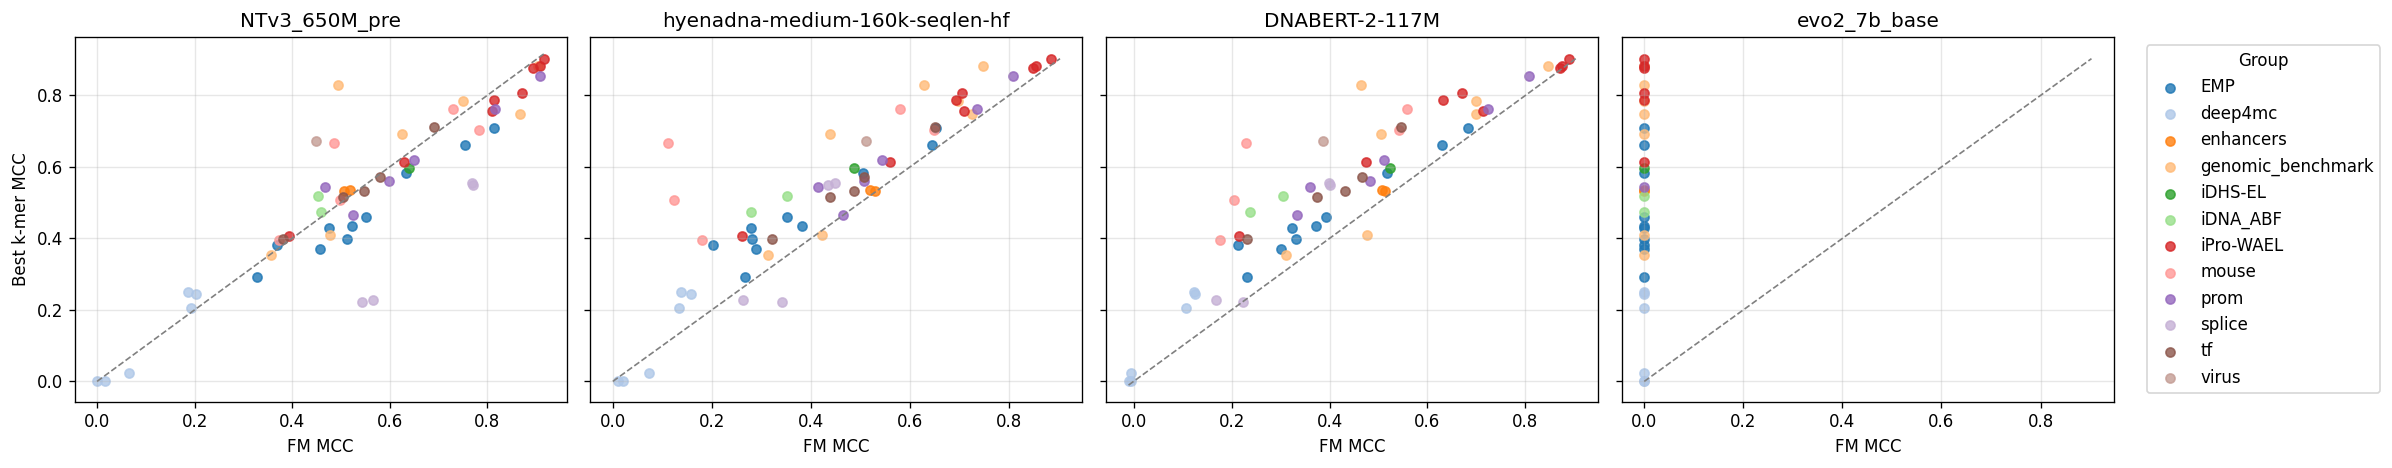

In [15]:
metric = 'MCC'  # cambia in AUROC/F1/Accuracy se serve

df = load_records()
cols_fm = fm_metric_cols(df, metric)
palette = dataset_palette(df)

best_k = best_kmer(df, metric)

n = len(cols_fm)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, cols_fm):
    x = pd.to_numeric(df[col], errors='coerce')
    y = best_k
    for g, sub in df.groupby('group'):
        ax.scatter(x.loc[sub.index], y.loc[sub.index], label=g, alpha=0.8, s=30, color=palette[g])
    lo = np.nanmin([x.min(), y.min()])
    hi = np.nanmax([x.max(), y.max()])
    ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1)
    ax.set_title(col.replace('fm_', '').replace('_' + metric, ''))
    ax.set_xlabel(f'FM {metric}')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(f'Best k-mer {metric}')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Group')
plt.tight_layout()


## 2) Vantaggio prestazioni / efficienza
Confronto il miglior k-mer con il miglior FM sulle classificazioni e, sotto, il tempo mediano di estrazione/inferenza nei benchmark di efficienza.

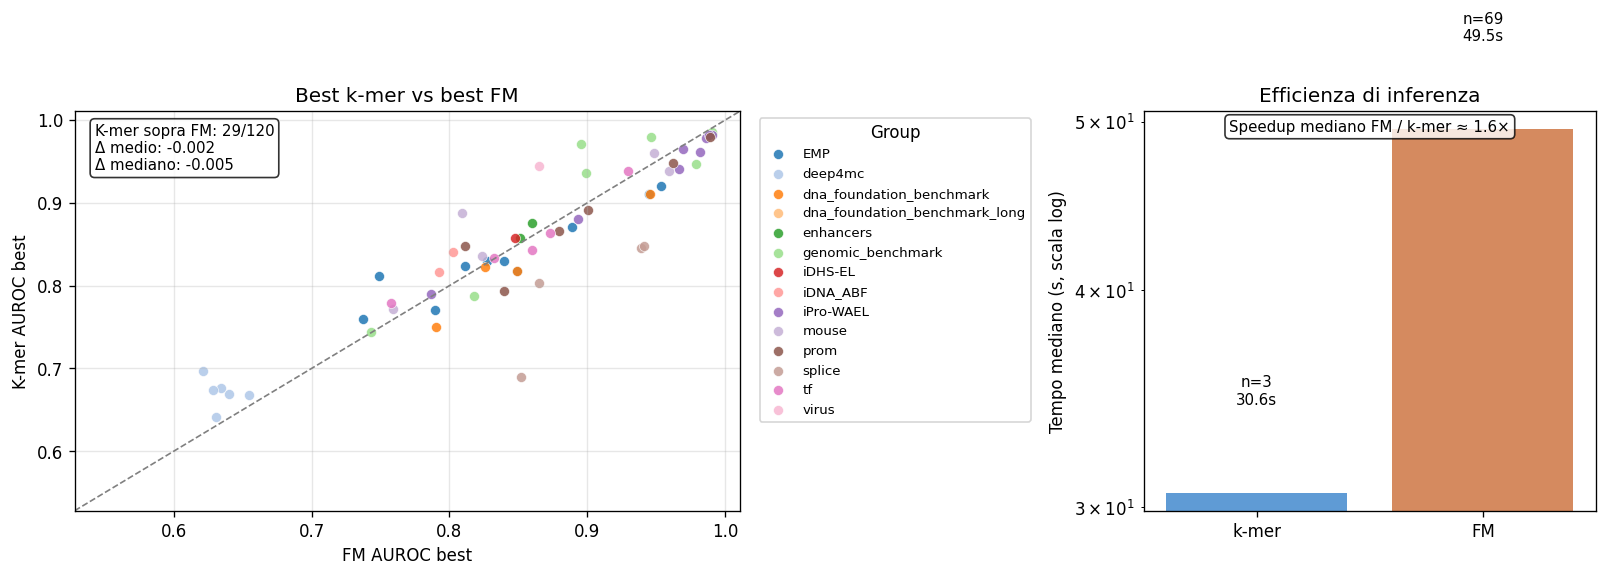

In [16]:
perf = pd.read_csv('../results/concat/best_perf_classification.csv')
perf['group'] = perf['dataset'].str.split('/').str[0]
perf['short'] = perf['dataset'].str.split('/').str[-1]
perf['delta_auc'] = perf['best_kmer_AUROC'] - perf['best_fm_AUROC']

palette_perf = dataset_palette(perf)

perf_wins = (perf['delta_auc'] > 0).sum()
perf_total = len(perf)
perf_mean = perf['delta_auc'].mean()
perf_median = perf['delta_auc'].median()

eff = pd.read_csv('../results/exploratory/efficiency.csv')
eff['time_sec'] = pd.to_numeric(eff['time_sec'], errors='coerce')
eff['family'] = eff['method'].apply(
    lambda method: 'k-mer' if str(method).startswith('kmer_') else ('FM' if str(method).startswith('fm_') else pd.NA)
)
eff = eff.dropna(subset=['family', 'time_sec']).copy()
eff_summary = (
    eff.groupby('family')['time_sec']
    .agg(['median', 'mean', 'count'])
    .reindex(['k-mer', 'FM'])
)

speedup = eff_summary.loc['FM', 'median'] / eff_summary.loc['k-mer', 'median']

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), gridspec_kw={'width_ratios': [1.25, 0.85]})

ax = axes[0]
for g, sub in perf.sort_values('delta_auc').groupby('group'):
    ax.scatter(
        sub['best_fm_AUROC'],
        sub['best_kmer_AUROC'],
        label=g,
        alpha=0.85,
        s=36,
        color=palette_perf[g],
        edgecolors='white',
        lw=0.4,
    )

lo = min(perf['best_fm_AUROC'].min(), perf['best_kmer_AUROC'].min()) - 0.02
hi = max(perf['best_fm_AUROC'].max(), perf['best_kmer_AUROC'].max()) + 0.02
ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel('FM AUROC best')
ax.set_ylabel('K-mer AUROC best')
ax.set_title('Best k-mer vs best FM')
ax.grid(True, alpha=0.3)
ax.text(
    0.03,
    0.97,
    f'K-mer sopra FM: {perf_wins}/{perf_total}\nΔ medio: {perf_mean:+.3f}\nΔ mediano: {perf_median:+.3f}',
    transform=ax.transAxes,
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Group', fontsize=8)

ax = axes[1]
summary_plot = eff_summary.reset_index()
sns.barplot(data=summary_plot, x='family', y='median', hue='family', ax=ax, palette=['#4C9BE8', '#E8854C'], legend=False)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('Tempo mediano (s, scala log)')
ax.set_title('Efficienza di inferenza')
ax.grid(True, alpha=0.3, axis='y')

for idx, row in summary_plot.iterrows():
    ax.text(
        idx,
        row['median'] * 1.12,
        f"n={int(row['count'])}\n{row['median']:.1f}s",
        ha='center',
        va='bottom',
        fontsize=9,
    )

ax.text(
    0.5,
    0.98,
    f'Speedup mediano FM / k-mer ≈ {speedup:.1f}×',
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
)

plt.tight_layout()


## 2) Performance task di regressione


In [17]:
# LRA regression tasks
lra = pd.read_csv(LRA)

# righe con R2 disponibili
reg = lra[lra['kmer_k4_R2'].notna()].copy()

# seleziona modelli e prepara long format
r2_cols = [c for c in reg.columns if c.endswith('_R2')]
reg_long = reg.melt(id_vars=['dataset'], value_vars=r2_cols, var_name='model', value_name='R2')
reg_long['R2'] = pd.to_numeric(reg_long['R2'], errors='coerce')
reg_long = reg_long.dropna()

plt.figure(figsize=(10, 5))
sns.barplot(data=reg_long, x='dataset', y='R2', hue='model')
plt.xticks(rotation=45, ha='right')
plt.title('R2 su task di regressione (LRA)')
plt.tight_layout()


FileNotFoundError: [Errno 2] No such file or directory: '../results/lra_records.csv'